# Anomaly detection using residuals

In this example we are using temperature data from NOAA. We requested data from station USC00290041 in Abiquiu, NM from 1980 to 2024. More information can be found here: https://www.ncei.noaa.gov/

Time series can be thought of as containing three components: 
1. Trend $(t_t)$: the general shape of the data over time
2. Seasonality $(s_t)$: Patterns based on time
3. Noise $(\epsilon_t)$: Random noise assumed to be normally distributed

Time series can be additive:

$x_t = t_t+s_t+\epsilon_t$

Or multiplicative:

$x_t = t_ts_t\epsilon_t$

For this example, we assume that the time series is additive. We use statsmodels seasonal decompose to break the time series into trend, seasonality, and residuals (noise). We can use the assumption that the residuals are normally distributed to identify anomalies. Here we use a simple rule of thumb: anything outside of 3 standard deviations of the mean is an outlier.

For more on statsmodels seasonal decompose: https://www.statsmodels.org/stable/generated/statsmodels.tsa.seasonal.seasonal_decompose.html

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

In [2]:
df = pd.read_csv('temperature_data.csv')
print(df.shape)
print(df.isna().sum())
df.head()

(16061, 5)
STATION      0
NAME         0
DATE         0
TMAX       174
TMIN       271
dtype: int64


,STATION,NAME,DATE,TMAX,TMIN
0,USC00290041,"ABIQUIU DAM, NM US",1980-01-01,42.0,16.0
1,USC00290041,"ABIQUIU DAM, NM US",1980-01-02,43.0,15.0
2,USC00290041,"ABIQUIU DAM, NM US",1980-01-03,30.0,18.0
3,USC00290041,"ABIQUIU DAM, NM US",1980-01-04,38.0,13.0
4,USC00290041,"ABIQUIU DAM, NM US",1980-01-05,47.0,13.0


In [3]:
# I find forward/back fill to work best for time series data
df['DATE'] = pd.to_datetime(df['DATE'])
df['TMAX'] = df['TMAX'].ffill()
df['TMIN'] = df['TMIN'].ffill()

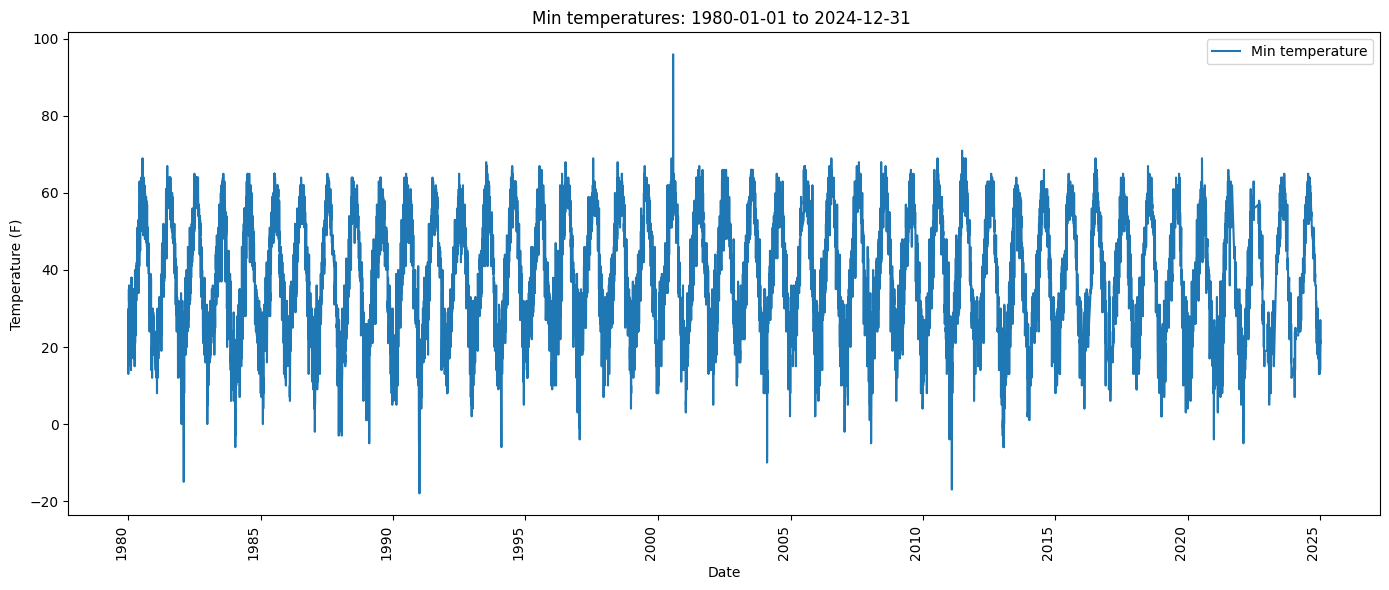

In [4]:
# plot data
fig, ax = plt.subplots(figsize=(14, 6))
plt.plot(df['DATE'], df['TMIN'], label = "Min temperature")
plt.legend()
plt.title(f'Min temperatures: {df['DATE'].min().date()} to {df['DATE'].max().date()} ')
plt.xlabel("Date")
plt.ylabel('Temperature (F)')
plt.xticks(rotation = 90, ha = 'right')
plt.tight_layout()
plt.show()

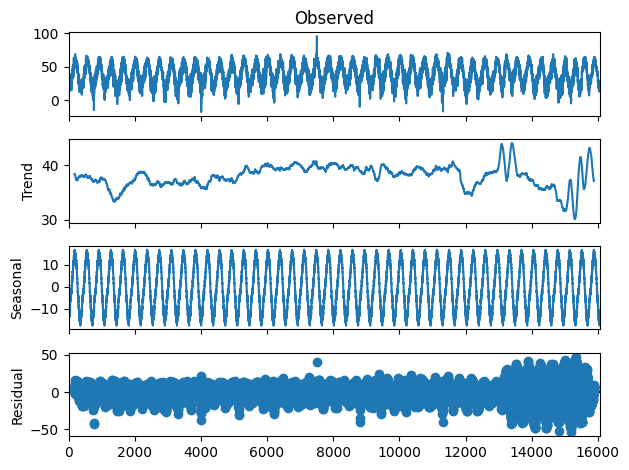

In [5]:
result = seasonal_decompose(list(df['TMIN'].dropna()), model='additive', period=365)
result.plot()
plt.show()

In [6]:
residuals_df = pd.DataFrame({'DATE':list(df['DATE']), 'residuals': list(result.resid)}).dropna()
mean_residual = residuals_df['residuals'].mean()
std_residual = residuals_df['residuals'].std()

print(f"Mean Residuals: {mean_residual}")
print(f"Standard Deviation of Residuals: {std_residual}")

Mean Residuals: -0.0011147429379376023
Standard Deviation of Residuals: 11.574293114362542


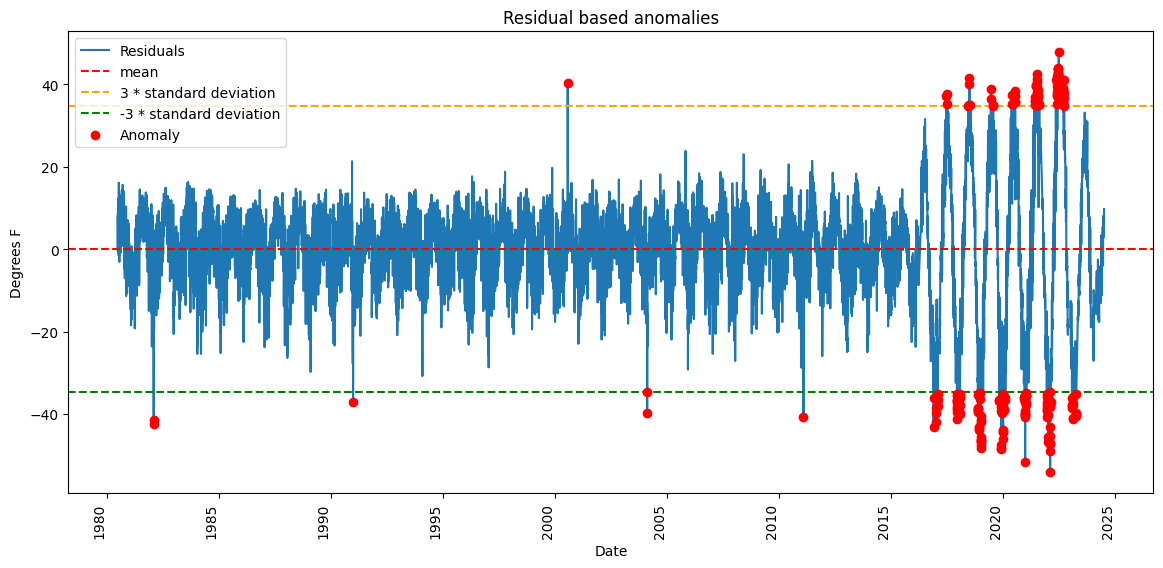

In [7]:
fig, ax = plt.subplots(figsize=(14, 6))
plt.plot(residuals_df['DATE'], residuals_df['residuals'], label = "Residuals")
plt.axhline(y=mean_residual, color='r', linestyle='--', label = "mean")
plt.axhline(y=mean_residual+3*std_residual, color='orange', linestyle='--', label = "3 * standard deviation")
plt.axhline(y=mean_residual-3*std_residual, color='green', linestyle='--', label = "-3 * standard deviation")
outliers = ((residuals_df['residuals']<-3*std_residual)|(residuals_df['residuals']>3*std_residual))
plt.scatter(
    residuals_df.loc[outliers, 'DATE'],
    residuals_df.loc[outliers, 'residuals'],
    color = 'red', label = 'Anomaly', zorder = 5
)
plt.xticks(rotation = 90, ha = 'right')
plt.title(f'Residual based anomalies')
plt.xlabel("Date")
plt.ylabel('Degrees F')
plt.legend()
plt.show()

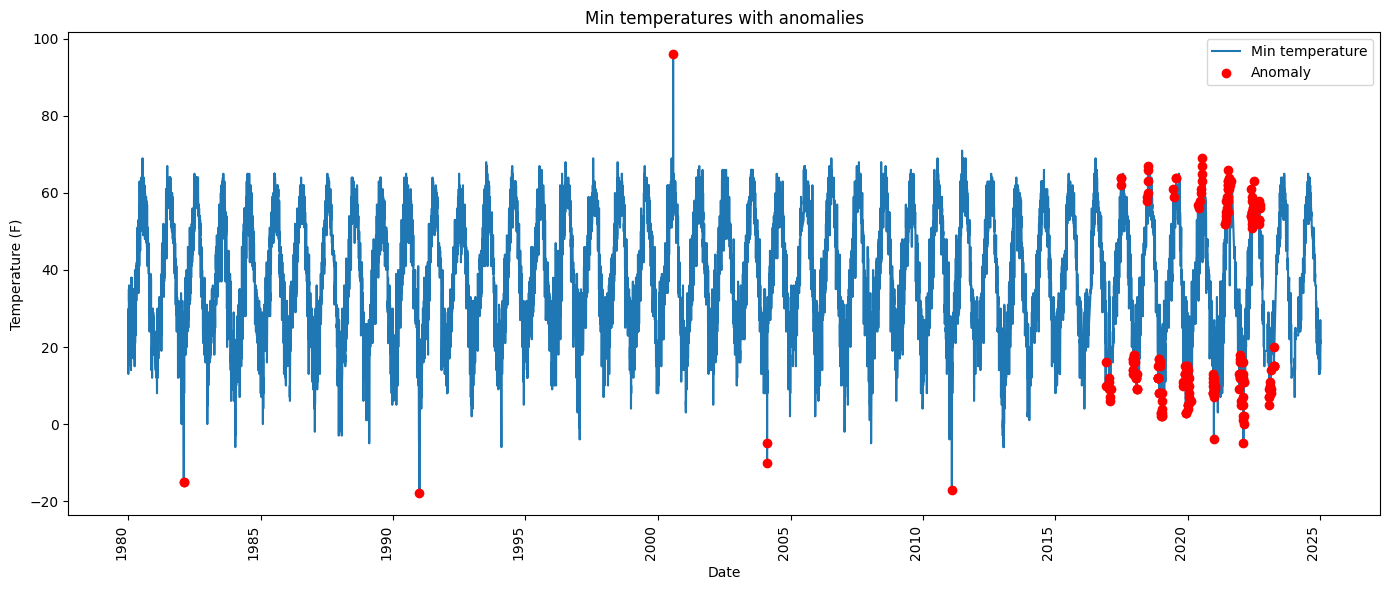

In [8]:
# plot data
fig, ax = plt.subplots(figsize=(14, 6))
plt.plot(df['DATE'], df['TMIN'], label = "Min temperature")
outlier_index = residuals_df.loc[outliers].index
plt.scatter(
    df.loc[outlier_index, 'DATE'],
    df.loc[outlier_index, 'TMIN'],
    color = 'red', label = 'Anomaly', zorder = 5
)
plt.legend()
plt.title(f'Min temperatures with anomalies')
plt.xlabel("Date")
plt.ylabel('Temperature (F)')
plt.xticks(rotation = 90, ha = 'right')
plt.tight_layout()
plt.show()

# What happens when we truncate the data?

In [9]:
recent_df = df[df['DATE']>'2016-01-01'].reset_index(drop = True).copy()

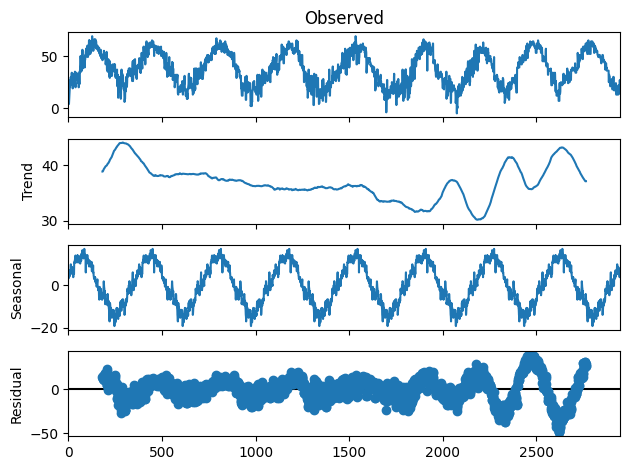

In [10]:
result_recent = seasonal_decompose(list(recent_df['TMIN'].dropna()), model='additive', period=365)
result_recent.plot()
plt.show()

In [11]:
residuals_df = pd.DataFrame({'DATE':list(recent_df['DATE']), 'residuals': list(result_recent.resid)}).dropna()
mean_residual = residuals_df['residuals'].mean()
std_residual = residuals_df['residuals'].std()

print(f"Mean Residuals: {mean_residual}")
print(f"Standard Deviation of Residuals: {std_residual}")

Mean Residuals: -0.39222462000375
Standard Deviation of Residuals: 13.335110264607545


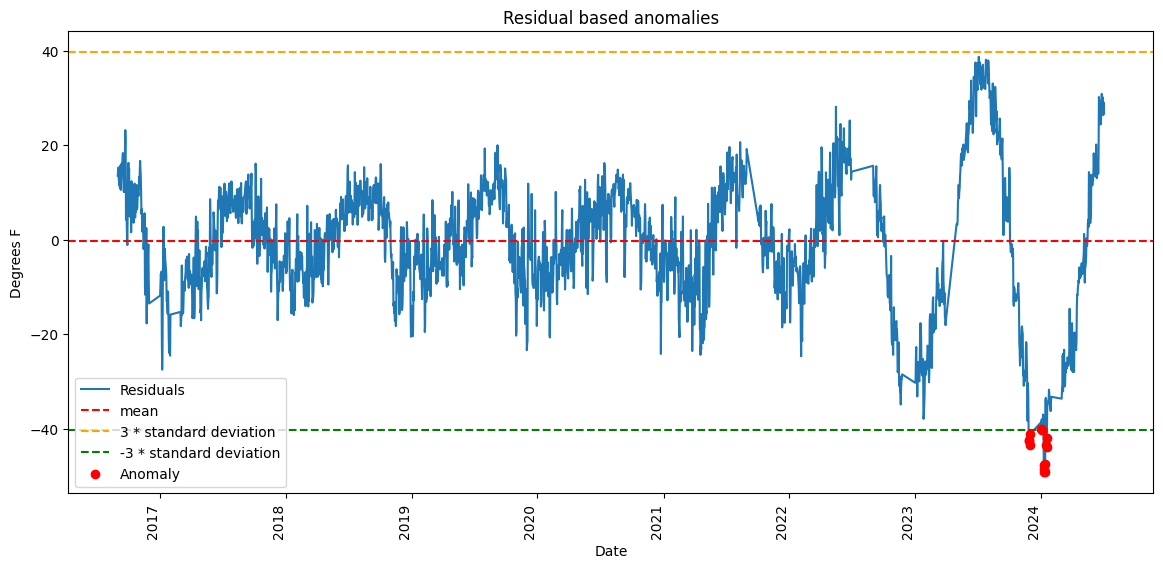

In [12]:
fig, ax = plt.subplots(figsize=(14, 6))
plt.plot(residuals_df['DATE'], residuals_df['residuals'], label = "Residuals")
plt.axhline(y=mean_residual, color='r', linestyle='--', label = "mean")
plt.axhline(y=mean_residual+3*std_residual, color='orange', linestyle='--', label = "3 * standard deviation")
plt.axhline(y=mean_residual-3*std_residual, color='green', linestyle='--', label = "-3 * standard deviation")
outliers = ((residuals_df['residuals']<-3*std_residual)|(residuals_df['residuals']>3*std_residual))
plt.scatter(
    residuals_df.loc[outliers, 'DATE'],
    residuals_df.loc[outliers, 'residuals'],
    color = 'red', label = 'Anomaly', zorder = 5
)
plt.xticks(rotation = 90, ha = 'right')
plt.title(f'Residual based anomalies')
plt.xlabel("Date")
plt.ylabel('Degrees F')
plt.legend()
plt.show()

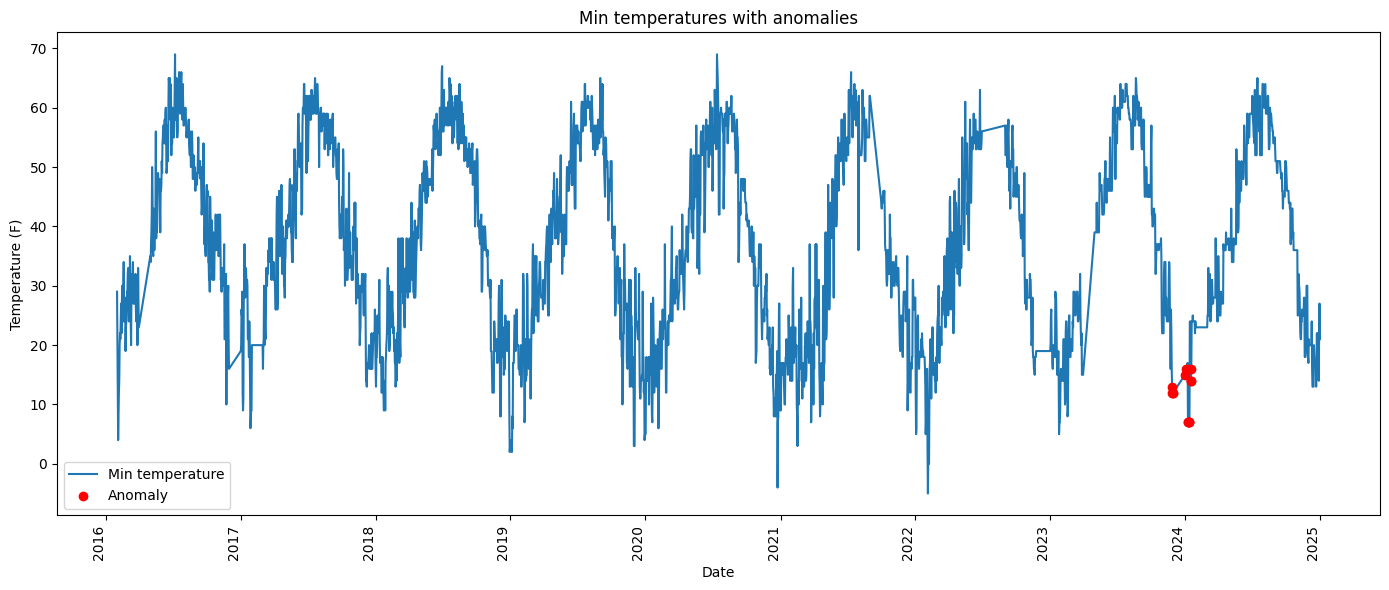

In [13]:
# plot data
fig, ax = plt.subplots(figsize=(14, 6))
plt.plot(recent_df['DATE'], recent_df['TMIN'], label = "Min temperature")
outlier_index = residuals_df.loc[outliers].index
plt.scatter(
    recent_df.loc[outlier_index, 'DATE'],
    recent_df.loc[outlier_index, 'TMIN'],
    color = 'red', label = 'Anomaly', zorder = 5
)
plt.legend()
plt.title(f'Min temperatures with anomalies')
plt.xlabel("Date")
plt.ylabel('Temperature (F)')
plt.xticks(rotation = 90, ha = 'right')
plt.tight_layout()
plt.show()